In [1]:
!pip3 install pydicom opencv-python matplotlib


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python3.13 -m pip install --upgrade pip


In [2]:
import os
import pydicom
import numpy as np
import cv2
import matplotlib.pyplot as plt

Loading CT and PET slices

In [3]:
print("Uploading CT")
upload_ct = "CT.zip"

Uploading CT


In [4]:
import zipfile
with zipfile.ZipFile("CT.zip", "r") as zip_ref:
  zip_ref.extractall("CT")


In [5]:
print("Uploading PET")
upload_pet = "PET.zip"

Uploading PET


In [6]:
with zipfile.ZipFile("PET.zip", "r") as zipPet_file:
  zipPet_file.extractall("PET")

Load the slices

In [7]:
ct_slices = [pydicom.dcmread(os.path.join("CT", f)) for f in os.listdir("CT") if f.endswith(".dcm")]
ct_slices = sorted(ct_slices, key=lambda s: float(s.ImagePositionPatient[2]))

pet_slices = [pydicom.dcmread(os.path.join("PET", f)) for f in os.listdir("PET") if f.endswith(".dcm")]
pet_slices = sorted(pet_slices, key=lambda s: float(s.ImagePositionPatient[2]))

In [8]:
def normalize(image):
  min_val = np.min(image)
  max_val = np.max(image)

  if(max_val - min_val == 0):
    return np.zeros_like(image)
  return (image - min_val) / (max_val - min_val)

Preprocess a CT DICOM slice

In [9]:
def preprocess_CT(dicom_slice):
  # converting to float values
  image = dicom_slice.pixel_array.astype(np.float32)
  # normalizing the pixel values to a range between 0 and 1
  image = normalize(image)

  image_resize = cv2.resize(image, (256,256))
  return image_resize


Preprocess PET slice

In [10]:
def preprocess_PET(dicom_slice):
  image = dicom_slice.pixel_array.astype(np.float32)
  image = normalize(image)

  image_resize = cv2.resize(image, (256,256))
  return image_resize

In [11]:
ct_processed = [preprocess_CT(s) for s in ct_slices]
pet_processed = [preprocess_PET(s) for s in pet_slices]

Visualizing the PreProcessed image

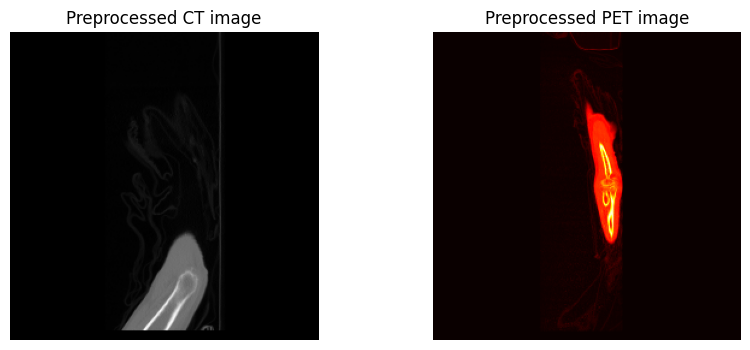

In [12]:
i = 0

plt.figure(figsize=(10,4))
plt.subplot(1, 2, 1)
plt.imshow(ct_processed[i], cmap="gray")
plt.title("Preprocessed CT image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(pet_processed[i], cmap="hot")
plt.title("Preprocessed PET image")
plt.axis("off")
plt.show()

Showing multiple slices of PET and CT

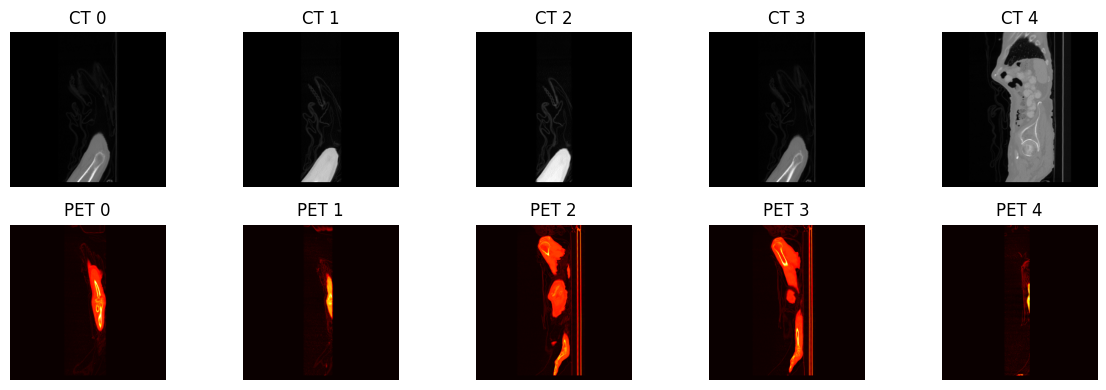

In [13]:
num_samples = min(5, len(ct_processed))

plt.figure(figsize=(12,4))

for i in range(num_samples):
  plt.subplot(2, num_samples, i + 1)
  plt.imshow(ct_processed[i], cmap="gray")
  plt.title(f"CT {i}")
  plt.axis("off")

  plt.subplot(2, num_samples, i+1+num_samples)
  plt.imshow(pet_processed[i], cmap="hot")
  plt.title(f"PET {i}")
  plt.axis("off")

plt.tight_layout()
plt.show()

Pix2Pix model - generator

1. Convolution layer

In [14]:
import torch
import torch.nn as nn

ModuleNotFoundError: No module named 'torch'

In [3]:
class DoubleConv(nn.Module):
  # creating a function that will take the number of outputs and desired # of feature maps
  def __init__(self, in_channel, out_channel):
    super().__init__()
    # building convolution layers that are sequential
    self.conv = nn.Sequential(
        nn.Conv2d(in_channel, out_channel, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channel, out_channel, kernel_size=3, padding=1),
        nn.ReLU(inplace=True)
    )
  def forward(self, x):
    return self.conv(x)


Encoder Block of UNet

In [4]:
class Encoder(nn.Module):
  def __init__(self, in_channel, out_channel):
    super().__init__()
    #Extract the features from the image
    self.doubleConv = DoubleConv(in_channel, out_channel)
    #Downsampling the image
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2) #Allows us to see the bigger picture

  def forward(self, x):
    x = self.doubleConv(x)
    x_down = self.pool(x)
    return x, x_down

Decoder Block of UNet

In [6]:
class Decoder(nn.Module):
  def __init__(self, in_channel, skip_c, out_channel):
    super().__init__()
    #ConvTranspose is a learnable way to increase image size
    self.upsample = nn.ConvTranspose2d(in_channel, out_channel, kernel_size=2, stride=2)
    self.conv = DoubleConv(in_channel=out_channel + skip_c, out_channel=out_channel)

  def forward(self, x, skip_c):
    x = self.upsample(x)
    x = torch.cat([x, skip_c], dim=1)
    return self.conv(x)


Full U-Net structure

In [8]:
class UNet(nn.Module):
  def __init__(self):
    super().__init__()
    # creating three encoder blocks
    self.encoder1 = Encoder(1, 16)
    self.encoder2 = Encoder(16, 32)
    self.encoder3 = Encoder(32, 64)

    # No need for nn.ReLU
    self.bottleneck = DoubleConv(64,128)

    self.decoder1 = Decoder(in_channel=128, skip_c=64, out_channel=64)
    self.decoder2 = Decoder(in_channel=64, skip_c=32, out_channel=32)
    self.decoder3 = Decoder(in_channel=32, skip_c=16, out_channel=16)

    self.finalConv = nn.Conv2d(16, 1, kernel_size=1) # given 16 outputs retrieve only 1
    self.activate = nn.Sigmoid()

  def forward(self, x):
    s1, x1 = self.encoder1(x)
    s2, x2 = self.encoder2(x1)
    s3, x3 = self.encoder3(x2)

    b = self.bottleneck(x3)

    d1 = self.decoder1(b, s3)
    d2 = self.decoder2(d1, s2)
    d3 = self.decoder3(d2, s1)

    return self.activate(self.finalConv(d3))



2. Discriminator, using PatchGAN model

In [9]:
class Discriminator(nn.Module):
  def __init__(self, in_channels=2):
    super().__init__()
    self.model = nn.Sequential(
        # Downsampling
        nn.Conv2d(in_channels, 64, kernel_size=4, stride=2, padding=1),
        nn.LeakyReLU(0.2, inplace=True),

        nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
        # normalize the batch to help with training
        nn.BatchNorm2d(128),
        nn.LeakyReLU(0.2, inplace=True),

        nn.Conv2d(128, 264, kernel_size=4, stride=2, padding=1),
        nn.BatchNorm2d(256),
        nn.LeakyReLU(0.2, inplace=True),

        nn.Conv2d(256, 512, kernel_size=4, stride=1, padding=1),
        nn.BatchNorm2d(512),
        nn.LeakyReLU(0.2, inplace=True),

        #converting the 512 features into a single output channel
        #This process will result in a small image where each pixel will represent the "realness" of a patch in the input
        #Sigmoid() will squash the output between 0 and 1

        nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=1),
        nn.Sigmoid()
    )
  def forward(self, ct_img, pet_img):
    #sending the ct image and pet image
    x = torch.cat([ct_img, pet_img], dim=1)
    return self.model(x)




Loss Function
1. adversarial loss

In [10]:
adversarial_criterion = nn.BCELoss() # measuring how well the generator can fool the discriminator
reconstruction_criterion = nn.L1Loss() # measuring how well the fake PET image is to real PET

In [ ]:
# Is out model able to identify real PET scans given a CT
pred_real = D()